# Exploratory Data Analysis


**Goal:** Exploratory analysis of the **DocSplit benchmark dataset**
in the poly_seq variant. We examine the distribution of document types,
package complexity, and source document diversity
to better understand the data before modeling.

In [1]:
import os
import json
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

## Configuration

In [2]:
BASE_DIR    = Path("../datasets/poly_seq/large")
OUTPUT_DIR  = Path("charts")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
SPLITS = ["train", "validation", "test"]

In [4]:
SPLIT_COLORS  = {"train": "#2563EB", "validation": "#16A34A", "test": "#DC2626"}
SPLIT_LABELS  = {"train": "Trening",  "validation": "Walidacja", "test": "Test"}

PALETTE = [
    "#0F172A",
    "#1E293B",
    "#334155",
    "#475569",
    "#0F766E",
    "#0EA5E9",
    "#2563EB",
    "#3B82F6",
    "#06B6D4",
    "#14B8A6",
    "#5B21B6",
    "#7C3AED",
    "#6366F1",
]
 
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

## Loading data

In [5]:
def build_dataframes() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    pages_list   = []
    subdocs_list = []
    packets_list = []
 
    for split in SPLITS:
        csv_path = BASE_DIR / f"{split}.csv"
        if not csv_path.exists():
            print(f"Missing file: {csv_path}")
            continue
 
        df = pd.read_csv(csv_path)
        df["split"] = split
        pages_list.append(df)
 
        json_dir = BASE_DIR / "ground_truth_json" / split
        if not json_dir.exists():
            print(f"Missing directiory: {json_dir}")
            continue
 
        for jf in sorted(json_dir.glob("*.json")):
            with open(jf) as f:
                pkt = json.load(f)
 
            doc_id      = pkt["doc_id"]
            total_pages = pkt["total_pages"]
            n_subdocs   = len(pkt["subdocuments"])
 
            packets_list.append({
                "split":       split,
                "doc_id":      doc_id,
                "total_pages": total_pages,
                "n_subdocs":   n_subdocs,
            })
 
            for sub in pkt["subdocuments"]:
                subdocs_list.append({
                    "split":        split,
                    "doc_id":       doc_id,
                    "doc_type":     sub["doc_type_id"],
                    "n_pages":      len(sub["page_ordinals"]),
                    "local_doc_id": sub["local_doc_id"],
                    "group_id":     sub["group_id"],
                })
 
    df_pages   = pd.concat(pages_list,   ignore_index=True) if pages_list   else pd.DataFrame()
    df_subdocs = pd.DataFrame(subdocs_list)
    df_packets = pd.DataFrame(packets_list)
 
    return df_pages, df_subdocs, df_packets

df_pages, df_subdocs, df_packets = build_dataframes()

In [6]:
def save_chart(fig, name: str) -> None:
    path = OUTPUT_DIR / name
    fig.savefig(path)
    plt.close(fig)

## Dataset Overview

In [7]:
def print_dataset_overview(df_subdocs, df_packets):
    splits = ["train", "validation", "test"]
    rows = []

    for split in splits:
        sd = df_subdocs[df_subdocs["split"] == split]
        pk = df_packets[df_packets["split"] == split]
        rows.append({
            "Split":               split.capitalize(),
            "Packets":             len(pk),
            "Subdocuments":        len(sd),
            "Unique doc types":    sd["doc_type"].nunique(),
            "Avg subdocs/packet":  round(pk["n_subdocs"].mean(), 2),
            "Avg pages/subdoc":    round(sd["n_pages"].mean(), 2),
            "Median pages/subdoc": int(sd["n_pages"].median()),
        })

    total_sd = df_subdocs
    total_pk = df_packets
    rows.append({
        "Split":               "Total",
        "Packets":             len(total_pk),
        "Subdocuments":        len(total_sd),
        "Unique doc types":    total_sd["doc_type"].nunique(),
        "Avg subdocs/packet":  round(total_pk["n_subdocs"].mean(), 2),
        "Avg pages/subdoc":    round(total_sd["n_pages"].mean(), 2),
        "Median pages/subdoc": int(total_sd["n_pages"].median()),
    })

    df_overview = pd.DataFrame(rows).set_index("Split")
    display(df_overview.style
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#1E3A5F"),
                ("color", "white"),
                ("font-weight", "500"),
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ]},
            {"selector": "tr:last-child td", "props": [
                ("font-weight", "500"),
                ("background-color", "#F0F4FF"),
            ]},
            {"selector": "tr:nth-child(even) td", "props": [
                ("background-color", "#F8F9FA"),
            ]},
            {"selector": "td", "props": [
                ("padding", "8px 16px"),
            ]},
        ])
        .format({
            "Packets":             "{:,}",
            "Subdocuments":        "{:,}",
            "Avg subdocs/packet":  "{:.2f}",
            "Avg pages/subdoc":    "{:.2f}",
            "Median pages/subdoc": "{:,}",
        })
    )

print_dataset_overview(df_subdocs, df_packets)

,Packets,Subdocuments,Unique doc types,Avg subdocs/packet,Avg pages/subdoc,Median pages/subdoc
Split,,,,,,
Train,"1,864","29,901",13,16.04,7.92,2
Validation,199,"2,209",13,11.10,7.16,2
Test,500,"6,178",13,12.36,5.66,2
Total,"2,563","38,288",13,14.94,7.51,2


The benchmark consists of 2,563 document packets containing 38,288 subdocuments across 13 document types. <br> The dataset is split into 
training (1,864 packets, 72.7%), test (500 packets, 19.5%), and validation (199 packets, 
7.8%) subsets.<br> The relatively small validation set may limit the reliability of 
hyperparameter tuning during model training.

## Document Type Distribution

The chart below shows the number of subdocuments per document type across all splits
combined, providing a first look at **class balance** in the benchmark.

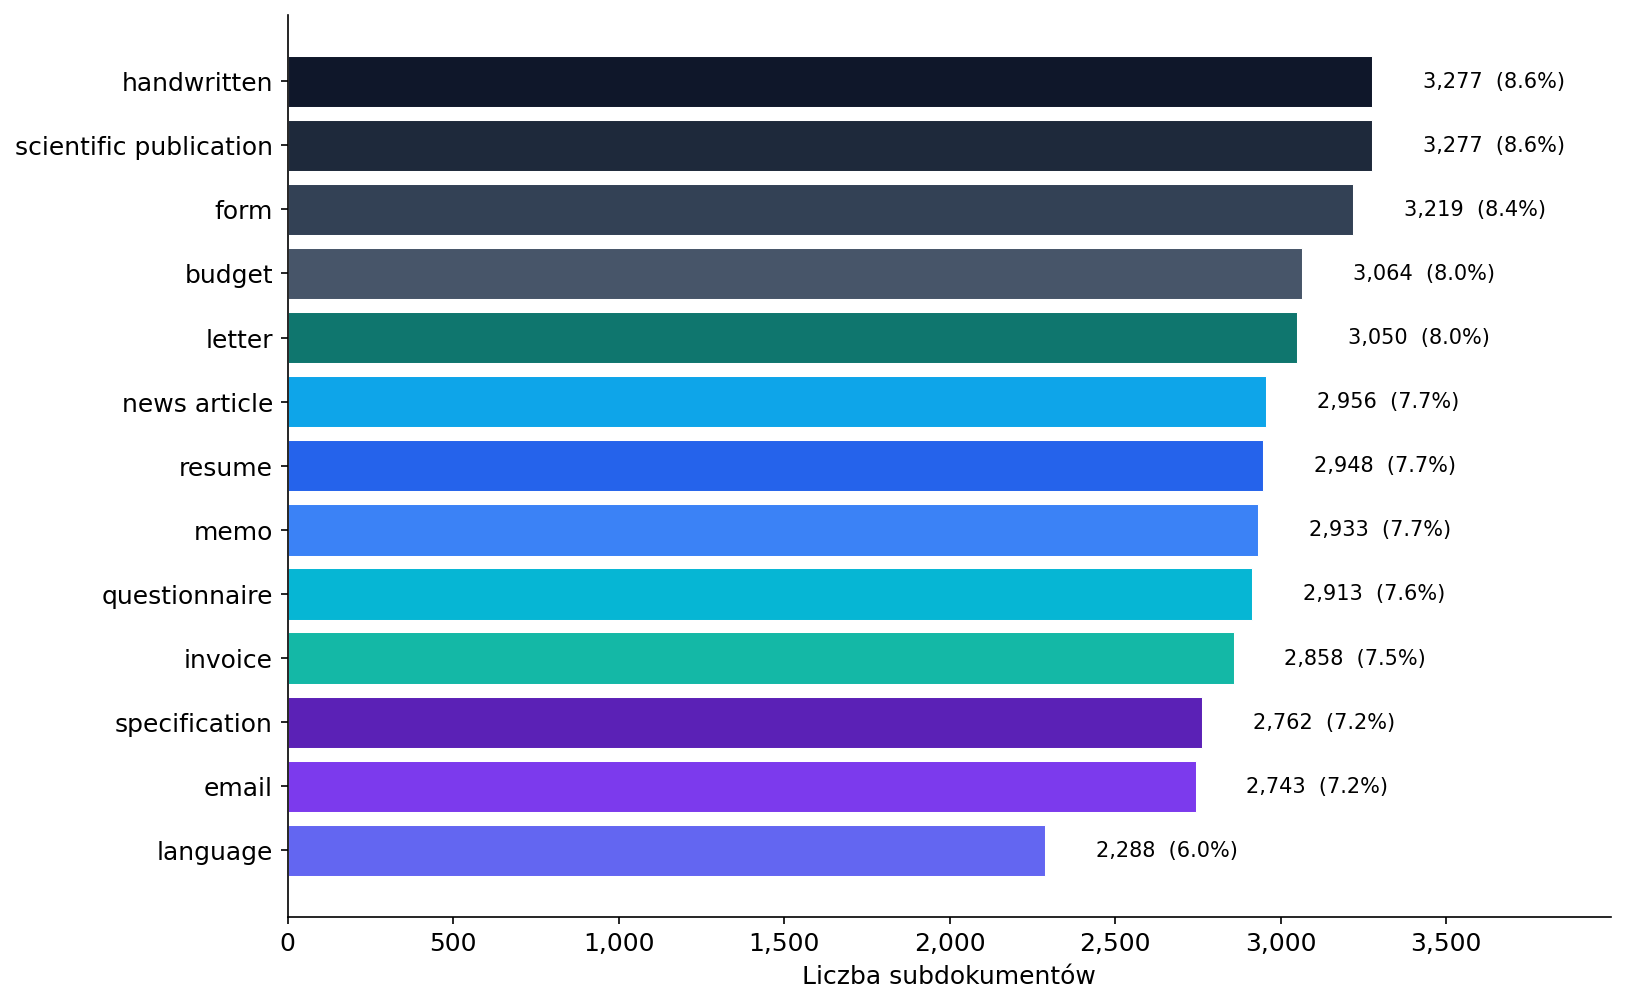

In [8]:
def plot_doc_type_distribution(df_subdocs):
    counts = df_subdocs["doc_type"].value_counts()
    total  = counts.sum()
 
    fig, ax = plt.subplots(figsize=(11, max(5, len(counts) * 0.45 + 1)))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=colors[::-1], edgecolor="white", linewidth=0.5)
 
    for bar, val in zip(bars, counts.values[::-1]):
        pct = val / total * 100
        ax.text(bar.get_width() + total * 0.004,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10)
 
    ax.set_xlabel("Liczba subdokumentów")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlim(0, counts.max() * 1.22)
    fig.tight_layout()
    plt.show()
    save_chart(fig, "01_doc_types_total.png")


plot_doc_type_distribution(df_subdocs)


The distribution is remarkably balanced given the diversity of document types.
**Handwritten** and **scientific publication** lead jointly at **3,277** subdocuments
each (8.6%), while **language** is the least represented at **2,288** (6.0%).
The difference between the most and least frequent class is only 989 subdocuments —
a relatively narrow gap suggesting the benchmark was deliberately constructed
to avoid severe class imbalance.

## Source Document Diversity

While the previous chart showed balanced subdocument counts, this chart examines
how many **unique source PDF files** underlie each type —
a measure of true data diversity.

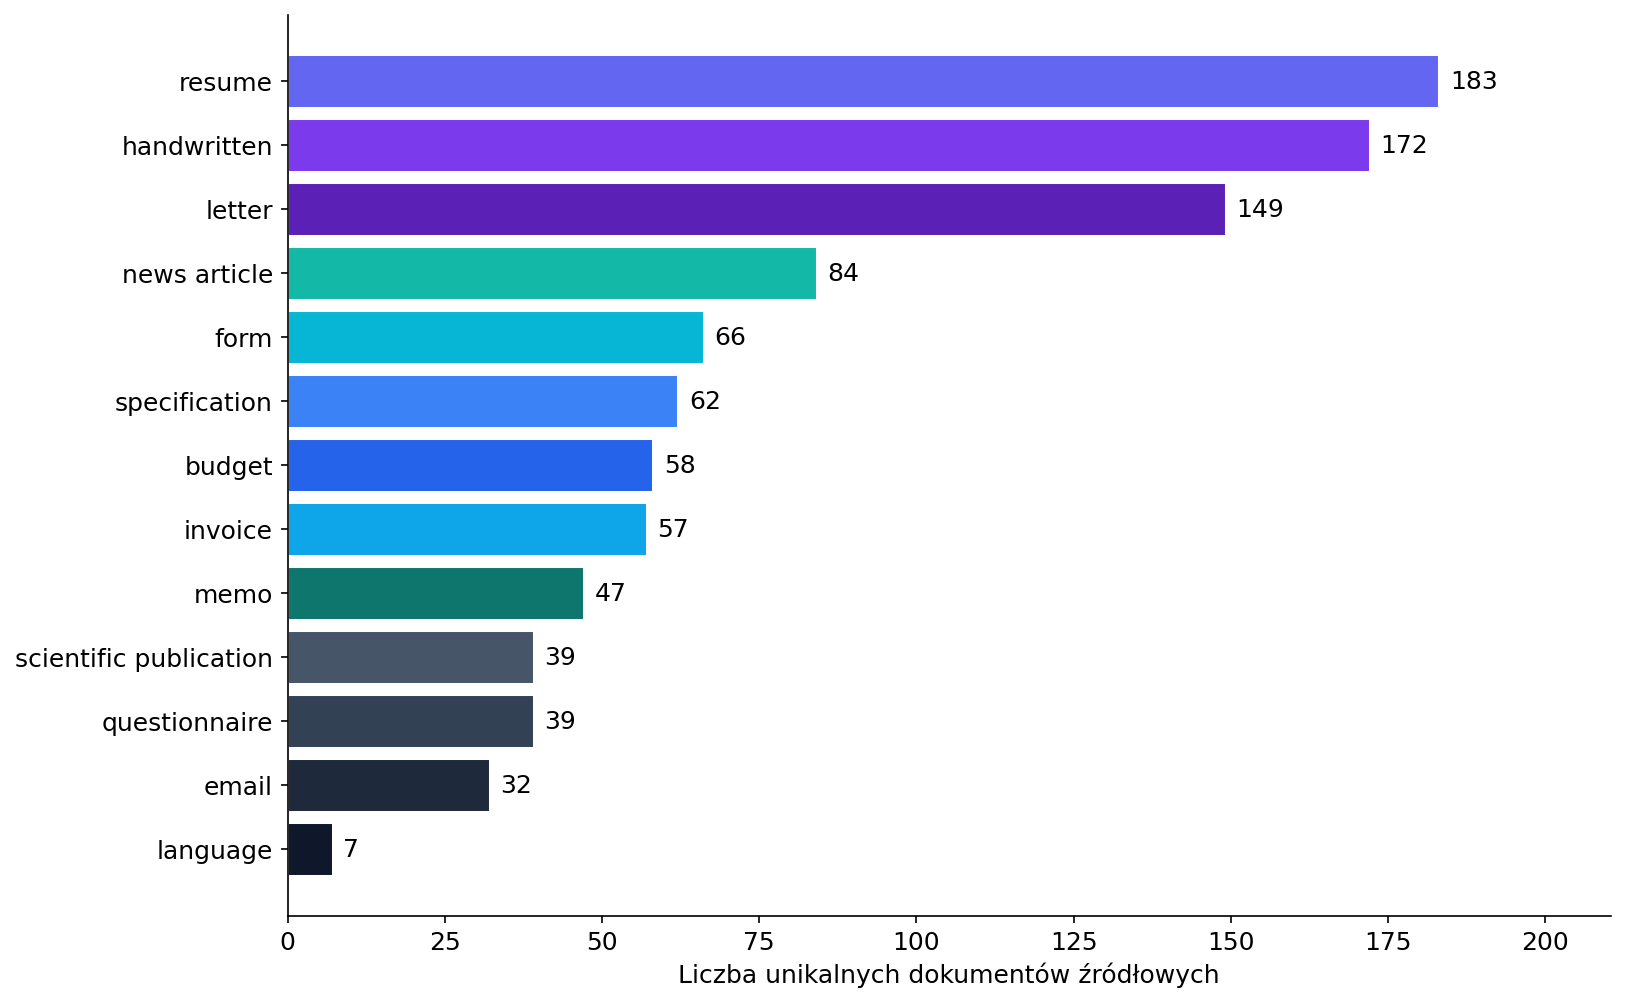

In [9]:
def plot_unique_docs(df_pages):
    unique = (df_pages.groupby("doc_type")["original_doc_name"]
              .nunique().sort_values(ascending=False))
 
    fig, ax = plt.subplots(figsize=(11, max(5, len(unique) * 0.45 + 1)))
    ax.barh(unique.index[::-1], unique.values[::-1],
            color=[PALETTE[i % len(PALETTE)] for i in range(len(unique))],
            edgecolor="white", linewidth=0.5)
 
    for i, (typ, val) in enumerate(zip(unique.index[::-1], unique.values[::-1])):
        ax.text(val + unique.max() * 0.01, i, f"{val:,}", va="center", fontsize=12)
 
    ax.set_xlabel("Liczba unikalnych dokumentów źródłowych")
    ax.set_xlim(0, unique.max() * 1.15)
    fig.tight_layout()
    plt.show()
    save_chart(fig, "02_unique_source_docs.png")


plot_unique_docs(df_pages)

The contrast with the previous chart is striking. Despite similar subdocument counts
across types, the number of unique source documents varies dramatically —
from **183** for **resume** down to just **7** for **language**.

This means *language* subdocuments are generated by repeatedly reusing the same
7 source files across many packets, while *resume* draws from a much richer pool.
Types with few unique sources — **language**, **email** (32),
**questionnaire** and **scientific publication** (39 each) — are at higher risk
of overfitting, as the model may learn document-specific visual patterns
rather than generalizable class features.

## Document Length Analysis

This boxplot examines the **distribution of page counts per subdocument** for each
document type, revealing how document length varies both within and across categories.

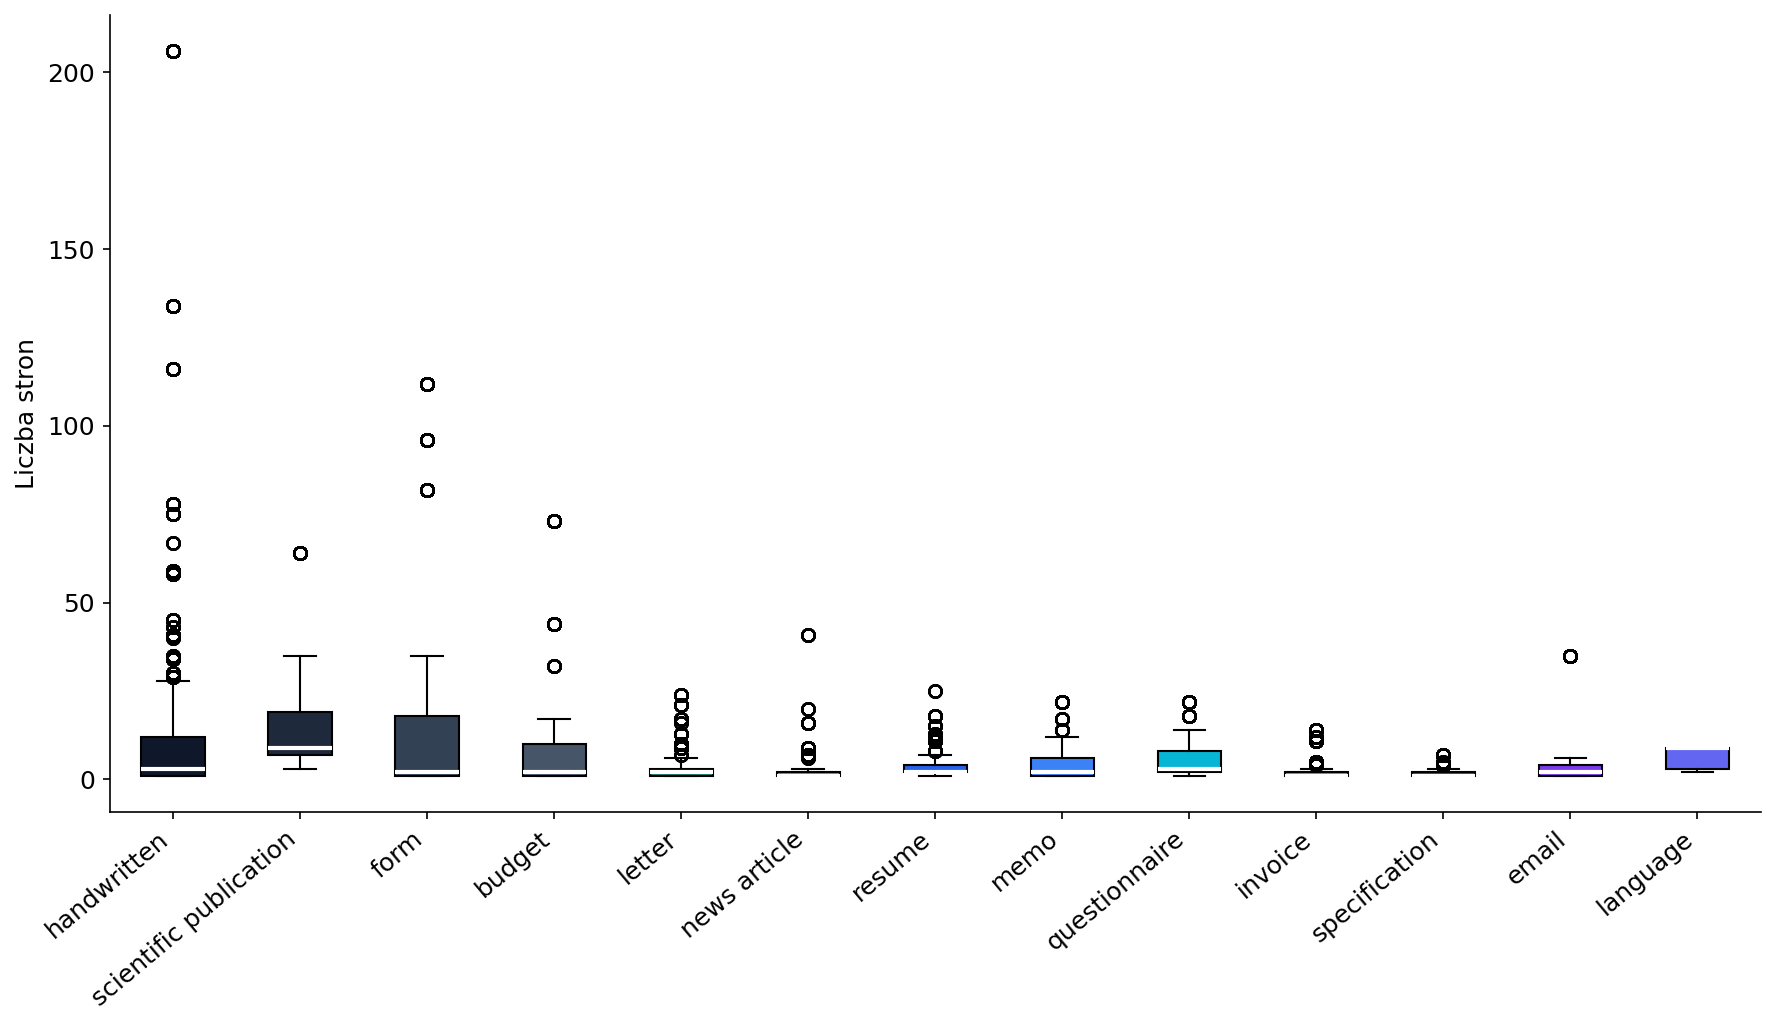

In [10]:
def plot_pages_boxplot(df_subdocs):
    fig, ax = plt.subplots(figsize=(12, 7))

    top_types = (
        df_subdocs["doc_type"]
        .value_counts()
        .index
        .tolist()
    )

    data_bp = [
        df_subdocs.loc[
            df_subdocs["doc_type"] == t,
            "n_pages"
        ].values
        for t in top_types
    ]

    bp = ax.boxplot(
        data_bp,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2)
    )

    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)

    ax.set_xticklabels(
        top_types,
        rotation=40,
        ha="right"
    )

    ax.set_ylabel("Liczba stron")

    fig.tight_layout()
    plt.show()
    save_chart(fig, "03_pages_boxplot.png")


plot_pages_boxplot(df_subdocs)

The plot reveals a clear separation between long-form and short-form document types:

- **Handwritten** documents exhibit the widest interquartile range and the single
  most extreme outlier in the dataset — exceeding **200 pages**.
- **Scientific publication** and **form** follow a similar pattern,
  with wide boxes and multiple high-value outliers.
- **Specification**, **invoice**, **email**, and **news article** are tightly
  compressed near the bottom of the scale, indicating consistently short documents.

This heterogeneity has direct implications for model design — architectures with
**fixed-length input windows** may require truncation strategies to handle
*handwritten* and *form* documents without information loss.

## Packet Complexity

The following histograms characterize the complexity of document packets in terms of
both the **number of constituent subdocuments** and the **total page count** per packet.

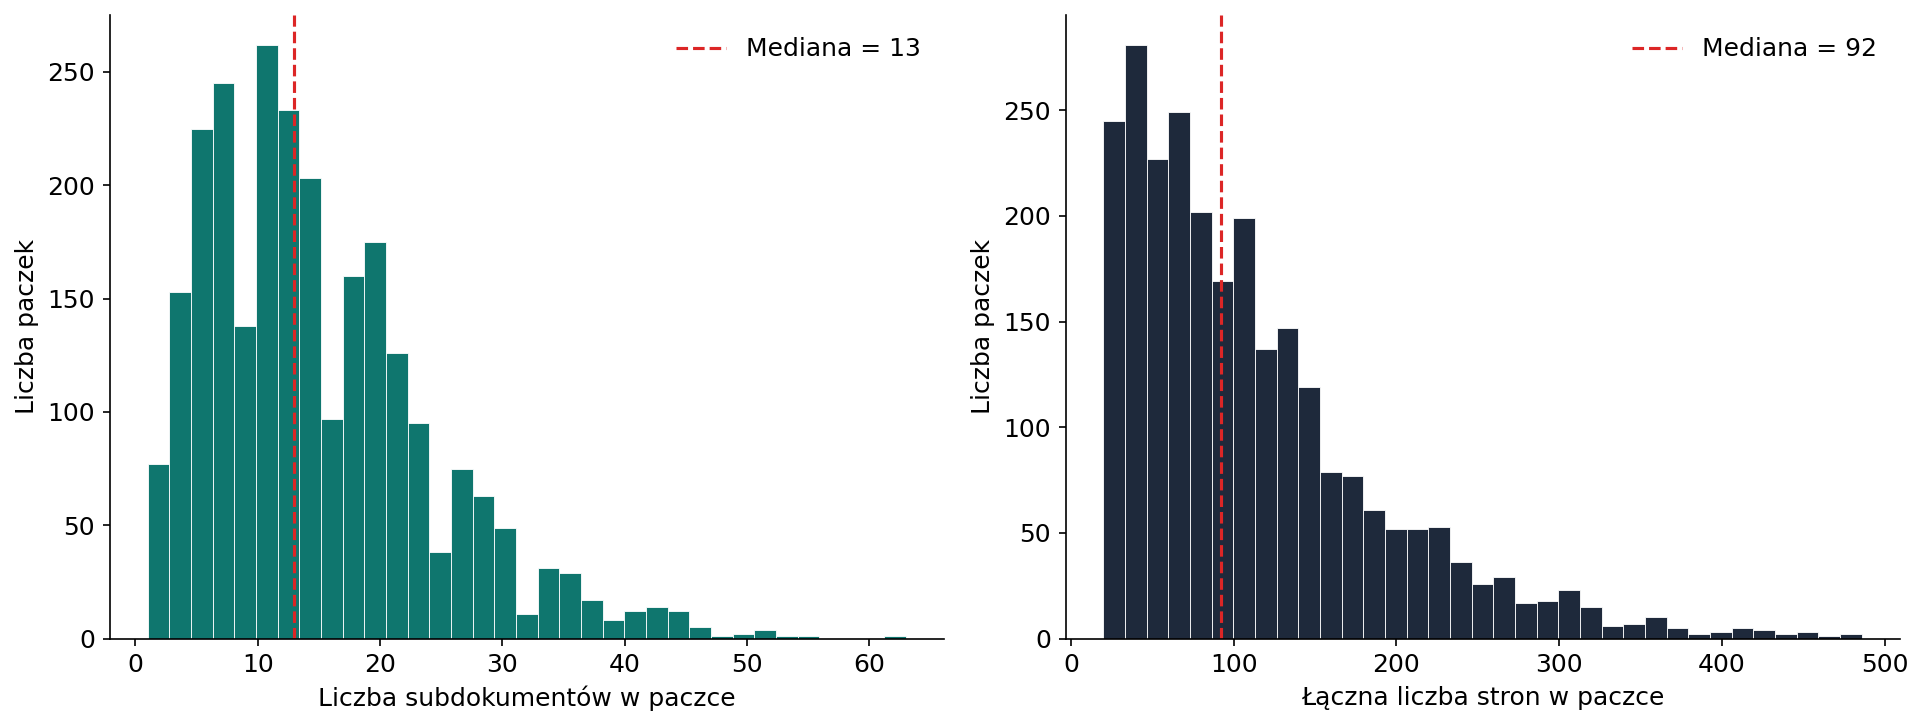

In [11]:
def plot_packet_complexity(df_packets):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
    for ax, col, color, xlabel, title in [
        (axes[0], "n_subdocs",   PALETTE[4],
         "Liczba subdokumentów w paczce", "Subdokumenty na paczkę"),
        (axes[1], "total_pages", PALETTE[1],
         "Łączna liczba stron w paczce",  "Strony na paczkę"),
    ]:
        ax.hist(df_packets[col], bins=35,
                color=color, edgecolor="white", linewidth=0.4)
        med = df_packets[col].median()
        ax.axvline(med, color="#DC2626", linestyle="--", linewidth=1.5,
                   label=f"Mediana = {med:.0f}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Liczba paczek")
        ax.legend(frameon=False)

    fig.tight_layout()
    plt.show()
    save_chart(fig, "04_packet_complexity.png")


plot_packet_complexity(df_packets)

Both distributions are **right-skewed**, with the bulk of packets concentrated
below the median yet a long tail extending to extreme values:

- **Median:** 13 subdocuments and 92 pages per packet
- **Maximum:** 63 subdocuments and 486 pages

A small but visible peak at the low end of both histograms indicates a subset
of simple, single- or few-document packets. This wide complexity range means that
**aggregated evaluation metrics alone may be misleading** — reporting performance
separately for simple and complex packets would provide a more complete picture
of model behaviour.

## Split Consistency

The heatmap shows the **percentage of each document type's subdocuments** assigned
to each split, allowing us to verify whether the train/validation/test division
is consistent across all 13 categories.

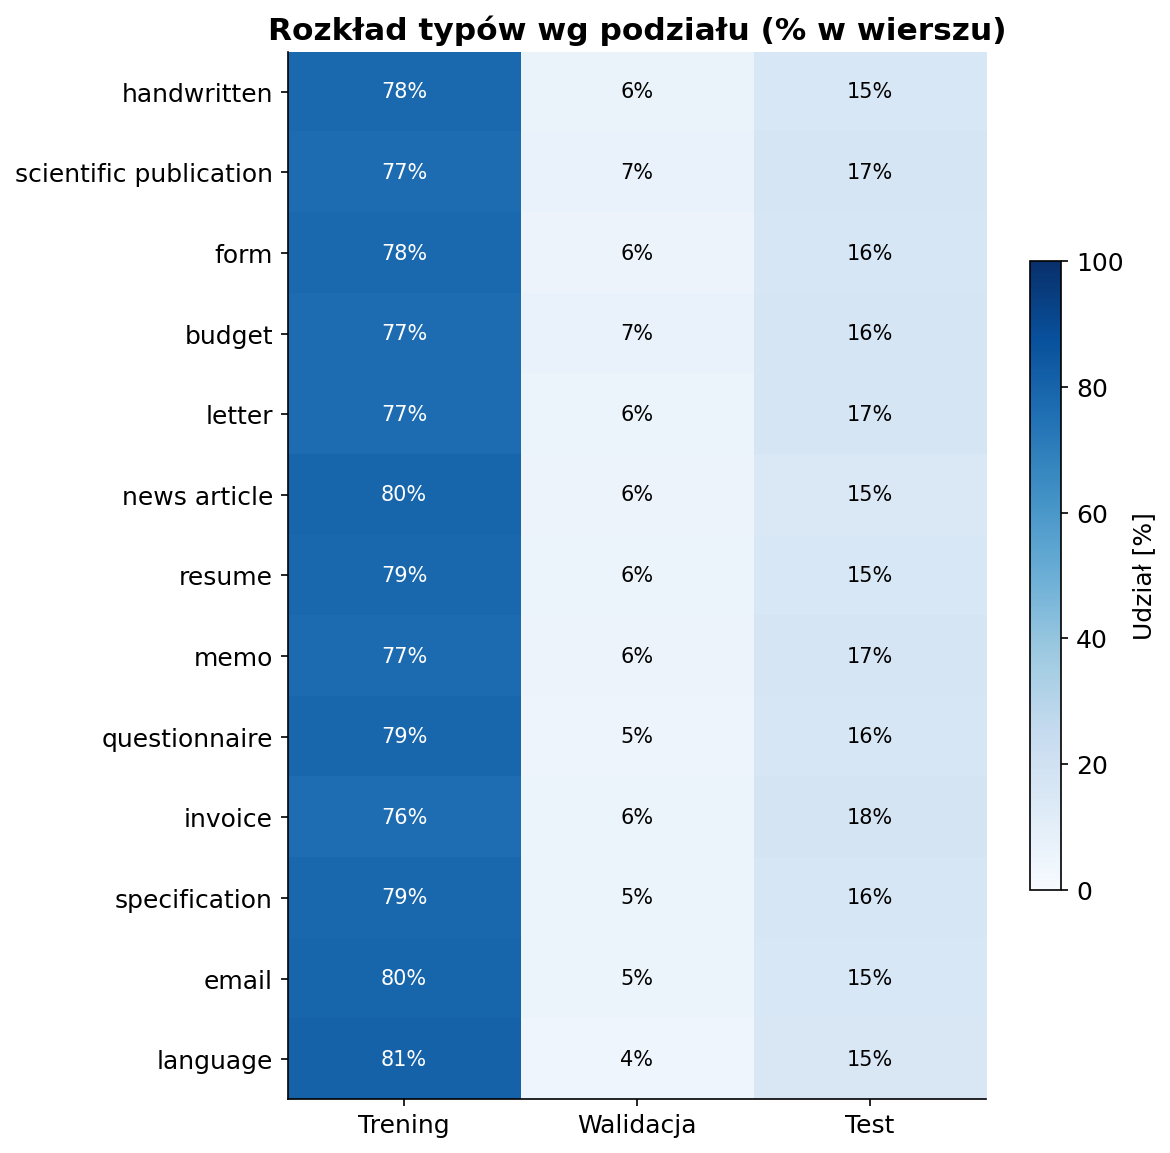

In [12]:
def plot_heatmap(df_subdocs):
    pivot = (df_subdocs.groupby(["doc_type", "split"])
             .size().unstack(fill_value=0))
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_norm = pivot_norm.loc[
        pivot.sum(axis=1).sort_values(ascending=False).index]
    cols = [c for c in SPLITS if c in pivot_norm.columns]
    data = pivot_norm[cols].values
 
    fig, ax = plt.subplots(figsize=(8, max(5, len(pivot_norm) * 0.45 + 2)))
    im = ax.imshow(data, aspect="auto", cmap="Blues", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label="Udział [%]", shrink=0.6)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([SPLIT_LABELS[c] for c in cols])
    ax.set_yticks(range(len(pivot_norm)))
    ax.set_yticklabels(pivot_norm.index)
 
    for i in range(len(pivot_norm)):
        for j in range(len(cols)):
            val = data[i, j]
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    color="white" if val > 55 else "black", fontsize=10)
 
    ax.set_title("Rozkład typów wg podziału (% w wierszu)")
    fig.tight_layout()
    plt.show()
    save_chart(fig, "05_heatmap_type_split.png")


plot_heatmap(df_subdocs)

The heatmap is visually uniform across all rows, confirming that the split ratio
is **consistent for every document type**:

| Split      | Share per type |
|------------|---------------|
| Training   | 76 – 81%      |
| Validation | 4 – 7%        |
| Test       | 15 – 18%      |

No type is disproportionately over- or under-represented in any split.
This **stratified consistency** ensures that evaluation results on the test set
are directly comparable across all document categories and are not distorted
by class distribution shifts between splits.